In [6]:
import numpy as np
import pandas as pd

def simular_economia(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                    rho=0.90, sigma_eps=0.02, T=50, seed=42,
                    con_inversion=True):

    np.random.seed(seed)

    eps = np.random.normal(0, sigma_eps, T)
    ln_A = np.zeros(T)

    for t in range(1, T):
        ln_A[t] = rho * ln_A[t - 1] + eps[t]

    A = np.exp(ln_A)

    k_ss = (alpha / (1 / beta - 1 + delta)) ** (1 / (1 - alpha))
    y_ss = k_ss ** alpha

    k = np.zeros(T + 1)
    y = np.zeros(T)
    c = np.zeros(T)
    i = np.zeros(T)
    b = np.zeros(T + 1)

    k[0] = k_ss
    b[0] = 0

    for t in range(T):

        y[t] = (A[t] * k[t]**alpha) if con_inversion else (y_ss * A[t])

        if con_inversion:
            k_opt = (alpha * A[t] / (r_star + delta)) ** (1 / (1 - alpha))
            k[t + 1] = 0.5 * k_opt + 0.5 * (1 - delta) * k[t]
            i[t] = k[t + 1] - (1 - delta) * k[t]
        else:
            k[t + 1] = k[t]
            i[t] = 0

        c[t] = (1 / (1 + beta)) * (y[t] + r_star * b[t] + beta * y_ss)
        b[t + 1] = (1 + r_star) * b[t] + y[t] - c[t] - i[t]

    CA = b[1:] - b[:-1]
    TB = y - c - i
    S = y + r_star * b[:-1] - c

    return pd.DataFrame({
        'Y': y,
        'C': c,
        'I': i,
        'S': S,
        'CA': CA,
        'TB': TB,
        'CA_Y': CA / y * 100,
        'TB_Y': TB / y * 100,
        'I_Y': i / y * 100,
        'S_Y': S / y * 100
    })

corr(CA/PIB, ciclo) con inversion = -0.033
corr(CA/PIB, ciclo) sin inversion = +0.318


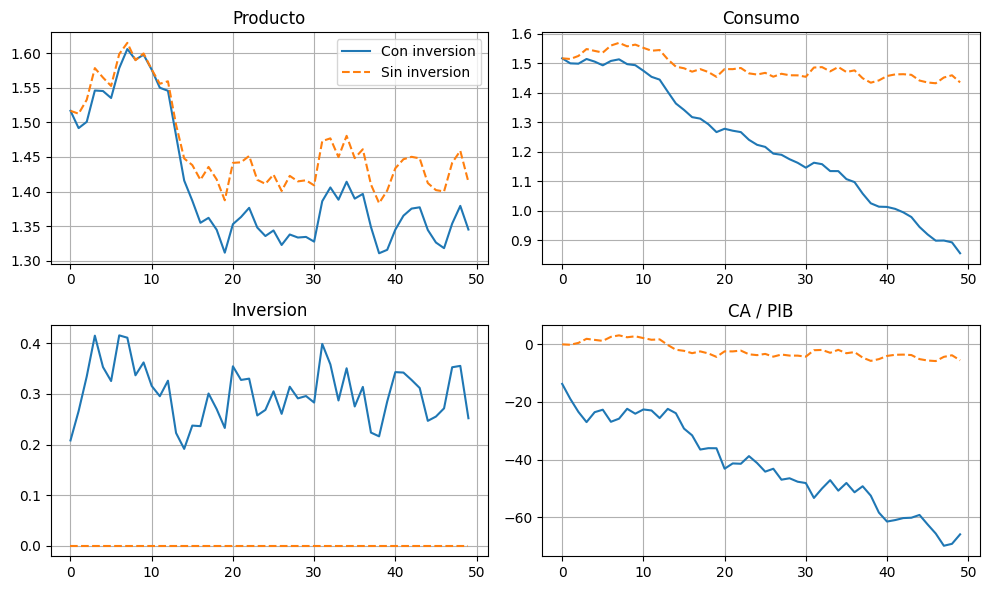

In [7]:
#Item 24

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter

# Simulaciones
df_inv = simular_economia(con_inversion=True)
df_dot = simular_economia(con_inversion=False)

# Filtro HP (sobre log del producto)
cycle_inv, _ = hpfilter(np.log(df_inv['Y']), lamb=6.25)
cycle_dot, _ = hpfilter(np.log(df_dot['Y']), lamb=6.25)

df_inv['Y_cycle'] = cycle_inv
df_dot['Y_cycle'] = cycle_dot

# Correlaciones
corr_inv = df_inv['CA_Y'].corr(df_inv['Y_cycle'])
corr_dot = df_dot['CA_Y'].corr(df_dot['Y_cycle'])

print(f"corr(CA/PIB, ciclo) con inversion = {corr_inv:+.3f}")
print(f"corr(CA/PIB, ciclo) sin inversion = {corr_dot:+.3f}")

# === Graficos ===
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# Producto
axs[0, 0].plot(df_inv['Y'], label='Con inversion')
axs[0, 0].plot(df_dot['Y'], linestyle='--', label='Sin inversion')
axs[0, 0].set_title('Producto')

# Consumo
axs[0, 1].plot(df_inv['C'])
axs[0, 1].plot(df_dot['C'], linestyle='--')
axs[0, 1].set_title('Consumo')

# Inversion
axs[1, 0].plot(df_inv['I'])
axs[1, 0].plot(df_dot['I'], linestyle='--')
axs[1, 0].set_title('Inversion')

# Cuenta corriente / PIB
axs[1, 1].plot(df_inv['CA_Y'])
axs[1, 1].plot(df_dot['CA_Y'], linestyle='--')
axs[1, 1].set_title('CA / PIB')

for ax in axs.flat:
    ax.grid()

axs[0,0].legend()
plt.tight_layout()
plt.show()


#En la economía sin inversión no existe acumulación, los agentes
#ahorran en momentos positivos y desahorran en una recesión. Por lo tanto,
#se puede observar comportamiento procíclico en cuanto a la CA. Asimismo,
#va de acorde al comportamiento de R1

#En la economía con inversión, en cambio, cuando hay un shock de productividad,
#por ejemplo, y la demanda por capital (para invertir) aumenta, lo que genera
#deficits externos y, por consecuencia, reducir la CA (contracíclica). Esto
#va de acorde al comportamiento de R2.

#R1 se asocia con la CA procíclica (aquí se da el suavizamiento de consumo)
# y R2 se asocia con la CA contracíclica (acumulación de capital), por
#lo tanto, el canal que se encuentra apagado en una economía de dotaciones
#es el de inversión (acumulación de capital).



In [9]:
#Item 25

import numpy as np
import pandas as pd
from statsmodels.tsa.filters.hp_filter import hpfilter

#funcion auxiliar
def momentos(df):
    cycle, _ = hpfilter(np.log(df['Y']), lamb=6.25)
    corr_CA = np.corrcoef(df['CA_Y'], cycle)[0,1]
    vol_I = np.std(df['I'])
    return corr_CA, vol_I

#Parámetros
base_params = dict(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                   rho=0.90, sigma_eps=0.02, T=200, seed=42,
                   con_inversion=True)

#funcion compara cambios
def comparar(param_name, valores):
    resultados = []

    for val in valores:
        params = base_params.copy()
        params[param_name] = val

        df = simular_economia(**params)
        corr_CA, vol_I = momentos(df)

        resultados.append((val, corr_CA, vol_I))

    return pd.DataFrame(resultados, columns=[param_name, 'corr_CA', 'vol_I'])

#simulaciones
res_rho = comparar('rho', [0.3, 0.7, 0.95])
res_alpha = comparar('alpha', [0.15, 0.33, 0.50])
res_r = comparar('r_star', [0.02, 0.04, 0.08])
res_sigma = comparar('sigma_eps', [0.01, 0.02, 0.04])
res_beta = comparar('beta', [0.90, 0.96, 0.99])

print("rho\n", res_rho, "\n")
print("alpha\n", res_alpha, "\n")
print("r*\n", res_r, "\n")
print("sigma_eps\n", res_sigma, "\n")
print("beta\n", res_beta)


res_rho['parametro'] = 'rho'
res_alpha['parametro'] = 'alpha'
res_r['parametro'] = 'r_star'
res_sigma['parametro'] = 'sigma_eps'
res_beta['parametro'] = 'beta'


tabla_total = pd.concat([
    res_rho, res_alpha, res_r, res_sigma, res_beta
], ignore_index=True)


tabla_total = tabla_total[['parametro', 'corr_CA', 'vol_I']]


tabla_total.to_csv("tabla_estatica_comparativa.csv", index=False)




rho
     rho   corr_CA     vol_I
0  0.30  0.008731  0.054183
1  0.70  0.011346  0.052598
2  0.95  0.012469  0.056373 

alpha
    alpha   corr_CA     vol_I
0   0.15  0.014853  0.013049
1   0.33  0.012125  0.054370
2   0.50  0.014668  0.257107 

r*
    r_star   corr_CA     vol_I
0    0.02 -0.014274  0.071246
1    0.04  0.012125  0.054370
2    0.08  0.009308  0.057943 

sigma_eps
    sigma_eps   corr_CA     vol_I
0       0.01  0.006158  0.028233
1       0.02  0.012125  0.054370
2       0.04  0.023932  0.108426 

beta
    beta   corr_CA     vol_I
0  0.90  0.012266  0.072130
1  0.96  0.012125  0.054370
2  0.99  0.013976  0.084475
Tabla unificada guardada.


'\n| Parámetro | Cambio | ΔI | ΔCA | Intuición                                                                                                                                  |\n| --------- | ------ | -- | --- | ------------------------------------------------------------------------------------------------------------------------------------------ |\n| ρ         | ↑      | ↑  | ↓   | Como shock es más persistente, el retorno esperado de capital es elevado y se incentiva a invertir hoy, esto incrementa el déficit externo |\n| α         | ↑      | ↑  | ↓   | Mayor peso de capital eleva la productividad marginal, aumenta inversion y mayor déficit en CA                                             |\n| r*        | ↑      | ↓  | ↑   | Mayor costo de financia. desincentiva inversión y reduce endeudamiento externo, por lo que CA aumenta                                      |\n| σ_ε       | ↑      | ↑  | ↓   | Shocks generan mayor fluctuacion en inversion, se amplifican los deficits y superav

In [10]:
#Item 26

  #Paso 1

import numpy as np
import pandas as pd

def simular_economia(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                    rho=0.90, sigma_eps=0.02, T=50, seed=42,
                    con_inversion=True):

    np.random.seed(seed)

    eps = np.random.normal(0, sigma_eps, T)
    ln_A = np.zeros(T)

    for t in range(1, T):
        ln_A[t] = rho * ln_A[t - 1] + eps[t]

    A = np.exp(ln_A)

    k_ss = (alpha / (1 / beta - 1 + delta)) ** (1 / (1 - alpha))
    y_ss = k_ss ** alpha

    k = np.zeros(T + 1)
    y = np.zeros(T)
    c = np.zeros(T)
    i = np.zeros(T)
    b = np.zeros(T + 1)

    k[0] = k_ss
    b[0] = 0

    for t in range(T):

        y[t] = (A[t] * k[t]**alpha) if con_inversion else (y_ss * A[t])

        if con_inversion:
            k_opt = (alpha * A[t] / (r_star + delta)) ** (1 / (1 - alpha))
            k[t + 1] = 0.5 * k_opt + 0.5 * (1 - delta) * k[t]
            i[t] = k[t + 1] - (1 - delta) * k[t]
        else:
            k[t + 1] = k[t]
            i[t] = 0

        c[t] = (1 / (1 + beta)) * (y[t] + r_star * b[t] + beta * y_ss)
        b[t + 1] = (1 + r_star) * b[t] + y[t] - c[t] - i[t]

    CA = b[1:] - b[:-1]
    TB = y - c - i
    S = y + r_star * b[:-1] - c

    return pd.DataFrame({
        'Y': y,
        'C': c,
        'I': i,
        'S': S,
        'CA': CA,
        'TB': TB,
        'CA_Y': CA / y * 100,
        'TB_Y': TB / y * 100,
        'I_Y': i / y * 100,
        'S_Y': S / y * 100
    })

def calcular_momentos(df):
    cycle, _ = hpfilter(np.log(df['Y']), lamb=6.25)
    corr_CA = np.corrcoef(df['CA_Y'], cycle)[0,1]
    corr_I = np.corrcoef(df['I'], cycle)[0,1]
    vol_ratio = np.std(df['I']) / np.std(df['C'])
    return corr_CA, corr_I, vol_ratio

#Parametros base
params_base = dict(
    alpha=0.33,
    beta=0.96,
    delta=0.10,
    r_star=0.04,
    rho=0.90,
    sigma_eps=0.02,
    T=200,
    seed=42,
    con_inversion=True
)

#Parametros calibrados
params_calibrados = dict(
    alpha=0.40,#mas inversión
    beta=0.96,
    delta=0.10,
    r_star=0.03,#mas endeudamiento externo
    rho=0.95,#mas persistencia
    sigma_eps=0.03,#mas volatilidad
    T=200,
    seed=42,
    con_inversion=True
)

#Simulacion
df_base = simular_economia(**params_base)
df_cal = simular_economia(**params_calibrados)


mom_base = calcular_momentos(df_base)
mom_cal = calcular_momentos(df_cal)

#Resultados
resultados = pd.DataFrame({
    'Momento': ['corr(CA, ciclo)', 'corr(I, ciclo)', 'σ(I)/σ(C)'],
    'Base': mom_base,
    'Calibrado': mom_cal
})

print(resultados.round(3))

resultados.round(3).to_csv("tabla_calibracion.csv", index=False)

#Incrementamos rho, alpha y sigma_e (para amplificar volatilidad de variables).
#Redujimos r*. Estos cambios llevan a mayor contraciclidad de CA y una mayor
#volatilidad en la inversión.




           Momento   Base  Calibrado
0  corr(CA, ciclo)  0.012      0.011
1   corr(I, ciclo)  0.634      0.551
2        σ(I)/σ(C)  0.012      0.059


In [11]:
#Paso 2

params_paper = dict(
    alpha=0.33,
    beta=0.999**4,#conversion trimestral a anual
    delta=0.058,
    r_star=0.04,
    rho=0.95,
    sigma_eps=0.035,#ajustado
    T=200,
    seed=42,
    con_inversion=True
)

#simulacion
df_paper = simular_economia(**params_paper)


from statsmodels.tsa.filters.hp_filter import hpfilter

cycle, _ = hpfilter(np.log(df_paper['Y']), lamb=6.25)

corr_CA = np.corrcoef(df_paper['CA_Y'], cycle)[0,1]
corr_I = np.corrcoef(df_paper['I'], cycle)[0,1]
vol_ratio = np.std(df_paper['I']) / np.std(df_paper['C'])

print("MOMENTOS MODELO CALIBRADO")
print(f"corr(CA, ciclo) = {corr_CA:+.3f}")
print(f"corr(I, ciclo) = {corr_I:+.3f}")
print(f"σ(I)/σ(C) = {vol_ratio:.3f}")

MOMENTOS MODELO CALIBRADO
corr(CA, ciclo) = +0.020
corr(I, ciclo) = +0.260
σ(I)/σ(C) = 0.044


In [13]:
#Paso 3:

import pandas as pd

#Calibracion del paso1
calibracion_p1 = {
    'alpha': 0.40,
    'beta': 0.96,
    'delta': 0.10,
    'r_star': 0.03,
    'rho': 0.95,
    'sigma_eps': 0.03
}

#Calibracion Chile
calibracion_paper = {
    'alpha': 0.33,
    'beta': 0.999**4,
    'delta': 0.058,
    'r_star': 0.04,
    'rho': 0.95,
    'sigma_eps': 0.035
}

#Tabka
tabla = pd.DataFrame({
    'Pais': ['Chile'] * len(calibracion_p1),
    'Parametro': list(calibracion_p1.keys()),
    'Calibracion_ojo': list(calibracion_p1.values()),
    'Calibracion_paper': list(calibracion_paper.values())
})

print(tabla.round(4))

tabla.round(4).to_csv("tabla_calibraciones_chile.csv", index=False)


#Simular_economía es una versión muy simple de una economia abierta. El
#paper incorpora shocks en los términos de cambios (como el cobre) que afectan
#directamente en la CA. También desgrega el gasto, lo que mueve bastante la
#dinámica entre el consumo y la inversion. Además, el paper incorpora un ambiente
#de dinámica inflacionaria y política monetaria que no se encuentran en este
#sencillo modelo.
#Los criterios del paper permiten modelar de forma más empírica sin la necesidad
#de ajustar demasiado los parámetros.

    Pais  Parametro  Calibracion_ojo  Calibracion_paper
0  Chile      alpha             0.40              0.330
1  Chile       beta             0.96              0.996
2  Chile      delta             0.10              0.058
3  Chile     r_star             0.03              0.040
4  Chile        rho             0.95              0.950
5  Chile  sigma_eps             0.03              0.035
